# ♻️ Reusable Linear Regression Project Template
A generic, parameterized notebook you can point at **any new dataset** with a
continuous outcome and a mix of numeric/categorical predictors. Fill in the **CONFIG**
cell, then run everything below top-to-bottom — the helper functions do the repeatable
work (loading, cleaning, EDA, outlier trimming, modeling, diagnostics, evaluation).

Demonstrated here against `psid_2017.csv`, but every function below is dataset-agnostic:
swap the CONFIG values to reuse this on a new project.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 2. CONFIG — the only cell you *must* edit for a new project

Everything below is written to read from this dictionary, so adapting this notebook to a
new dataset is mostly a matter of updating these values.

In [2]:
CONFIG = {
    "csv_path": "psid_2017.csv",
    "index_col": 0,

    # Sentinel/missing codes to replace with NaN, per column
    "sentinel_codes": {
        "age": [999],
        "education_years": [99],
    },

    # Rows to keep: (column, min, max) numeric range filters, applied in order
    "range_filters": [
        ("age", 25, 65),
    ],

    # Rows to keep: (column, condition) — condition is a function(series) -> bool mask
    "condition_filters": [
        ("labor_income", lambda s: s > 0),
    ],

    # Columns that must be non-null after all filtering
    "required_non_null": ["education_years"],

    # The outcome variable, and whether to log-transform it (recommended for
    # right-skewed continuous outcomes like income, price, duration, counts)
    "outcome": "labor_income",
    "log_transform_outcome": True,

    # Categorical recoding: {new_column: {old_value: new_label}} — unmapped values become NaN
    "categorical_recodes": {
        "gender_label": {"__source_col__": "gender", 1: "Male", 2: "Female"},
        "degree_tier": {
            "__source_col__": "highest_degree",
            "no college": "No college", "other": "No college",
            "associate": "Some college", "bachelor": "Some college",
            "master": "Graduate", "doctorate": "Graduate",
            "juris doctorate": "Graduate", "medical degree": "Graduate",
        },
    },

    # Binary flags: {new_column: (source_col, value_that_means_true)}
    "binary_flags": {
        "is_married": ("married", 1),
    },

    # Formula predictors for the simple model (must be a single numeric column)
    "simple_predictor": "education_years",

    # Formula RHS for the multiple model (raw string, referencing recoded/engineered columns)
    "multi_formula_rhs": "education_years + age + age_sq + C(gender_label) + C(degree_tier) + is_married",

    "test_size": 0.2,
    "random_state": 42,
    "iqr_k": 1.5,
}


## 3. Reusable Functions

In [3]:
def load_data(config):
    """Load the raw CSV."""
    return pd.read_csv(config["csv_path"], index_col=config.get("index_col"))


def clean_sentinels(df, config):
    """Replace known sentinel/missing codes with NaN, column by column."""
    df = df.copy()
    for col, codes in config.get("sentinel_codes", {}).items():
        n_bad = df[col].isin(codes).sum()
        if n_bad:
            print(f"  {col}: replacing {n_bad} sentinel-coded rows with NaN")
        df[col] = df[col].replace(codes, np.nan)
    return df


def apply_filters(df, config):
    """Apply numeric range filters and arbitrary boolean condition filters in sequence."""
    df = df.copy()
    for col, lo, hi in config.get("range_filters", []):
        before = len(df)
        df = df[(df[col] >= lo) & (df[col] <= hi)]
        print(f"  range filter {col} in [{lo},{hi}]: {before} -> {len(df)} rows")
    for col, cond in config.get("condition_filters", []):
        before = len(df)
        df = df[cond(df[col])]
        print(f"  condition filter on {col}: {before} -> {len(df)} rows")
    required = config.get("required_non_null", [])
    if required:
        before = len(df)
        df = df.dropna(subset=required)
        print(f"  drop rows missing {required}: {before} -> {len(df)} rows")
    return df


def apply_recodes(df, config):
    """Create recoded categorical columns and binary flags from CONFIG."""
    df = df.copy()
    for new_col, mapping in config.get("categorical_recodes", {}).items():
        mapping = dict(mapping)
        source_col = mapping.pop("__source_col__")
        df[new_col] = df[source_col].map(mapping)
    for new_col, (source_col, true_value) in config.get("binary_flags", {}).items():
        df[new_col] = (df[source_col] == true_value).astype(int)
    return df


def add_outcome(df, config):
    """Add a (possibly log-transformed) outcome column called 'model_outcome'."""
    df = df.copy()
    outcome = config["outcome"]
    if config.get("log_transform_outcome"):
        df["model_outcome"] = np.log(df[outcome])
        print(f"  model_outcome = log({outcome})  (skew before: {df[outcome].skew():.2f}, "
              f"after: {df['model_outcome'].skew():.2f})")
    else:
        df["model_outcome"] = df[outcome]
    return df


def trim_outliers_iqr(df, column, k=1.5):
    """Drop rows outside the IQR fences of `column`. Returns the trimmed df."""
    q1, q3 = df[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    before = len(df)
    trimmed = df[(df[column] >= lo) & (df[column] <= hi)]
    print(f"  IQR trim on {column} (k={k}): bounds [{lo:.2f},{hi:.2f}], "
          f"{before} -> {len(trimmed)} rows")
    return trimmed


def eda_report(df, numeric_cols, outcome_col):
    """Print correlations and show scatterplots of each numeric predictor vs outcome."""
    for col in numeric_cols:
        r, p = stats.pearsonr(df[col], df[outcome_col])
        print(f"{col:>20s} vs {outcome_col}: r = {r:6.3f}, p = {p:.2e}")
    fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
    if len(numeric_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_cols):
        sns.scatterplot(data=df, x=col, y=outcome_col, alpha=0.4, ax=ax)
    plt.tight_layout()
    plt.show()


def fit_ols(df, formula):
    """Fit an OLS model via a formula string, e.g. 'model_outcome ~ x1 + C(x2)'."""
    return smf.ols(formula, data=df).fit()


def fit_summary_table(model):
    """Coefficient table with percentage-effect column (valid if outcome is log-scale)."""
    table = model.params.to_frame("coefficient")
    table["pct_effect_if_log_outcome"] = (np.exp(table["coefficient"]) - 1) * 100
    table["p_value"] = model.pvalues
    table["ci_low"], table["ci_high"] = model.conf_int()[0], model.conf_int()[1]
    return table.round(4)


def residual_diagnostics(model, figsize=(11, 4)):
    """Plot residuals-vs-fitted and a Q-Q plot for a fitted statsmodels OLS model."""
    fitted, resid = model.fittedvalues, model.resid
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].scatter(fitted, resid, alpha=0.4)
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set(xlabel="Fitted values", ylabel="Residuals", title="Residuals vs Fitted")
    sm.qqplot(resid, line="45", fit=True, ax=axes[1])
    axes[1].set_title("Normal Q-Q")
    plt.tight_layout()
    plt.show()


def evaluate_on_test(model, test_df, outcome_col="model_outcome"):
    """Return a dict of test-set R2, RMSE, and a naive-baseline RMSE for comparison."""
    preds = model.predict(test_df)
    r2 = r2_score(test_df[outcome_col], preds)
    rmse = np.sqrt(mean_squared_error(test_df[outcome_col], preds))
    baseline_pred = np.full(len(test_df), model.model.endog.mean())
    baseline_rmse = np.sqrt(mean_squared_error(test_df[outcome_col], baseline_pred))
    return {
        "test_r2": r2, "test_rmse": rmse, "baseline_rmse": baseline_rmse,
        "improvement_vs_baseline_pct": (1 - rmse / baseline_rmse) * 100,
    }


def compute_vif(df, columns):
    """Variance Inflation Factors for the given (already-encodable) columns."""
    X = pd.get_dummies(df[columns], drop_first=True)
    X = sm.add_constant(X.astype(float))
    return pd.DataFrame({
        "variable": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    }).query("variable != 'const'").sort_values("VIF", ascending=False).reset_index(drop=True)


def compare_models(model_a, model_b, label_a="model_a", label_b="model_b"):
    """Side-by-side R2 / adjusted R2 + nested F-test between two OLS models."""
    print(f"{label_a}: R2={model_a.rsquared:.4f}  Adj.R2={model_a.rsquared_adj:.4f}")
    print(f"{label_b}: R2={model_b.rsquared:.4f}  Adj.R2={model_b.rsquared_adj:.4f}")
    return anova_lm(model_a, model_b)


print("Helper functions loaded:")
for fn in [load_data, clean_sentinels, apply_filters, apply_recodes, add_outcome,
           trim_outliers_iqr, eda_report, fit_ols, fit_summary_table,
           residual_diagnostics, evaluate_on_test, compute_vif, compare_models]:
    print(" -", fn.__name__)


Helper functions loaded:
 - load_data
 - clean_sentinels
 - apply_filters
 - apply_recodes
 - add_outcome
 - trim_outliers_iqr
 - eda_report
 - fit_ols
 - fit_summary_table
 - residual_diagnostics
 - evaluate_on_test
 - compute_vif
 - compare_models


## 4. Run the Pipeline

In [4]:
print("Loading data...")
raw = load_data(CONFIG)
print(raw.shape)


Loading data...


(26445, 9)


In [5]:
print("Cleaning sentinel codes...")
df = clean_sentinels(raw, CONFIG)


Cleaning sentinel codes...
  age: replacing 50 sentinel-coded rows with NaN
  education_years: replacing 420 sentinel-coded rows with NaN


In [6]:
print("Applying filters...")
df = apply_filters(df, CONFIG)


Applying filters...
  range filter age in [25,65]: 26445 -> 13790 rows
  condition filter on labor_income: 13790 -> 922 rows
  drop rows missing ['education_years']: 922 -> 881 rows


In [7]:
print("Applying categorical recodes and flags...")
df = apply_recodes(df, CONFIG)
df = df.dropna(subset=list(CONFIG["categorical_recodes"].keys()))
print(f"  after dropping unmapped categories: {len(df)} rows")


Applying categorical recodes and flags...
  after dropping unmapped categories: 871 rows


In [8]:
print("Adding (log) outcome...")
df = add_outcome(df, CONFIG)


Adding (log) outcome...
  model_outcome = log(labor_income)  (skew before: 4.65, after: -0.88)


     education_years vs model_outcome: r =  0.032, p = 3.40e-01
                 age vs model_outcome: r =  0.074, p = 3.00e-02


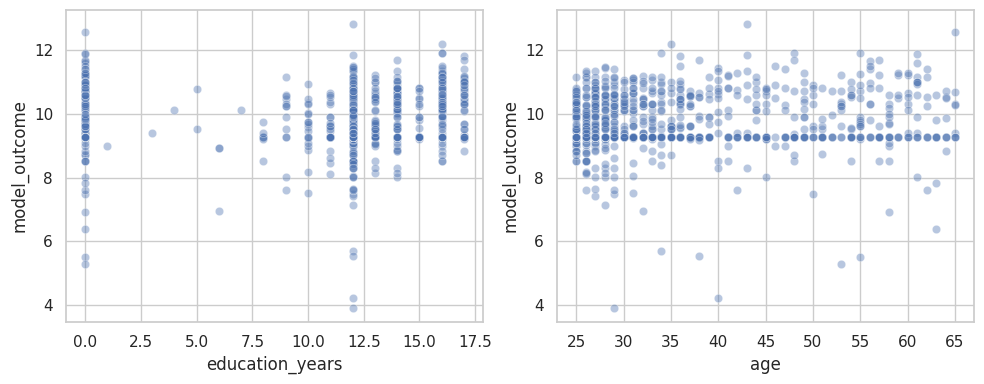

In [9]:
df["age_sq"] = df["age"] ** 2  # example engineered feature; add more as needed
eda_report(df, numeric_cols=[CONFIG["simple_predictor"], "age"], outcome_col="model_outcome")


In [10]:
clean_df = trim_outliers_iqr(df, "model_outcome", k=CONFIG["iqr_k"])


  IQR trim on model_outcome (k=1.5): bounds [7.53,12.22], 871 -> 855 rows


In [11]:
train, test = train_test_split(
    clean_df, test_size=CONFIG["test_size"], random_state=CONFIG["random_state"]
)
print(f"Train: {len(train)}   Test: {len(test)}")


Train: 684   Test: 171


In [12]:
simple_formula = f"model_outcome ~ {CONFIG['simple_predictor']}"
model_simple = fit_ols(train, simple_formula)
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:          model_outcome   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.2361
Date:                Sat, 22 Aug 2026   Prob (F-statistic):              0.627
Time:                        18:16:12   Log-Likelihood:                -808.55
No. Observations:                 684   AIC:                             1621.
Df Residuals:                     682   BIC:                             1630.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           9.8015      0.065    1

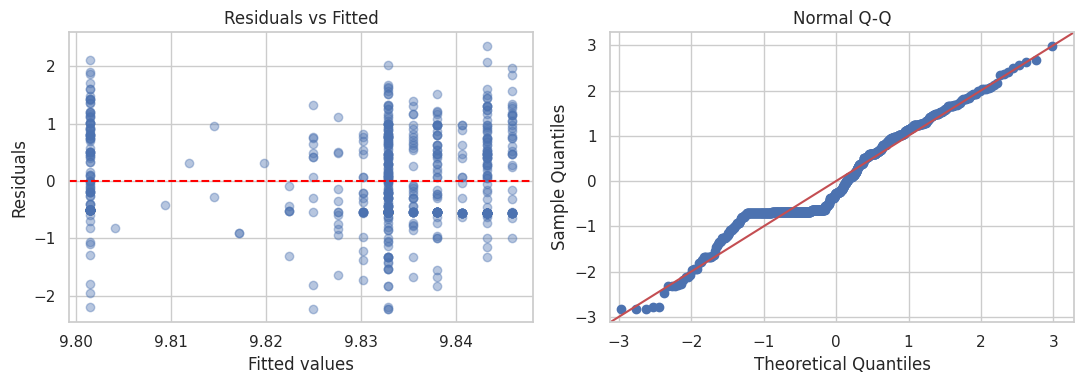

In [13]:
residual_diagnostics(model_simple)


In [14]:
fit_summary_table(model_simple)


,coefficient,pct_effect_if_log_outcome,p_value,ci_low,ci_high
Intercept,9.8015,1.805952e+06,0.0000,9.6743,9.9287
education_years,0.0026,2.616000e-01,0.6272,-0.0079,0.0132


In [15]:
multi_formula = f"model_outcome ~ {CONFIG['multi_formula_rhs']}"
model_multi = fit_ols(train, multi_formula)
print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:          model_outcome   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     7.353
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           1.59e-08
Time:                        18:16:12   Log-Likelihood:                -783.57
No. Observations:                 684   AIC:                             1583.
Df Residuals:                     676   BIC:                             1619.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

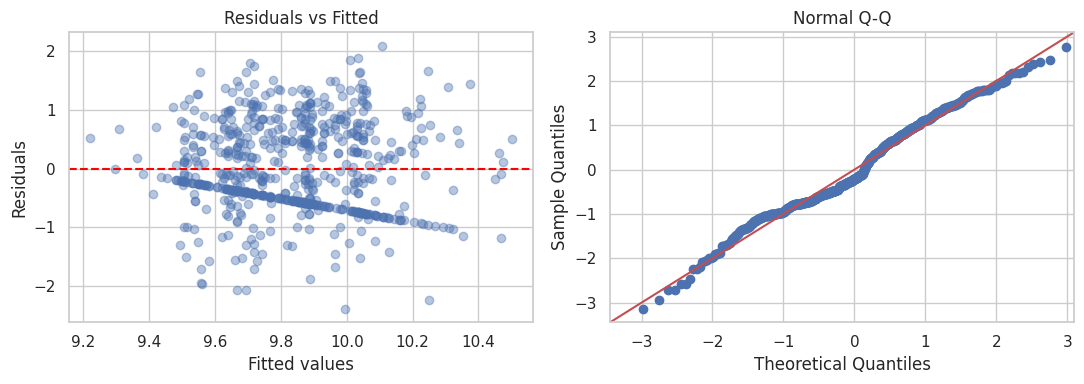

In [16]:
residual_diagnostics(model_multi)


In [17]:
compare_models(model_simple, model_multi, "simple", "multi")


simple: R2=0.0003  Adj.R2=-0.0011
multi: R2=0.0708  Adj.R2=0.0611


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,682.0,425.919941,0.0,NaN,NaN,NaN
1,676.0,395.920063,6.0,29.999878,8.537042,5.868048e-09


In [18]:
vif_cols = [CONFIG["simple_predictor"], "age", "age_sq", "gender_label", "degree_tier", "is_married"]
compute_vif(train, vif_cols)


,variable,VIF
0,age_sq,100.352225
1,age,87.573859
2,degree_tier_No college,5.109862
3,education_years,4.588387
4,degree_tier_Some college,4.394404
5,is_married,1.079395
6,gender_label_Male,1.044895


In [19]:
fit_summary_table(model_multi)


,coefficient,pct_effect_if_log_outcome,p_value,ci_low,ci_high
Intercept,8.9292,754804.9881,0.0000,8.0097,9.8487
C(gender_label)[T.Male],0.1603,17.3805,0.0083,0.0414,0.2791
C(degree_tier)[T.No college],-0.4425,-35.7582,0.0073,-0.7653,-0.1198
C(degree_tier)[T.Some college],-0.0805,-7.7316,0.6275,-0.4060,0.2450
education_years,0.0074,0.7405,0.5087,-0.0145,0.0293
age,0.0454,4.6454,0.0526,-0.0005,0.0913
age_sq,-0.0004,-0.0367,0.2136,-0.0009,0.0002
is_married,-0.3324,-28.2793,0.0046,-0.5617,-0.1031


In [20]:
print("Simple model test performance:", evaluate_on_test(model_simple, test))
print("Multi model test performance:  ", evaluate_on_test(model_multi, test))


Simple model test performance: {'test_r2': -0.005111759529627724, 'test_rmse': np.float64(0.7218431609610443), 'baseline_rmse': np.float64(0.7206758105240492), 'improvement_vs_baseline_pct': np.float64(-0.16197996657418834)}
Multi model test performance:   {'test_r2': 0.04066898827566079, 'test_rmse': np.float64(0.7052123528504456), 'baseline_rmse': np.float64(0.7206758105240492), 'improvement_vs_baseline_pct': np.float64(2.145688456278161)}


## 5. How to Reuse This on a New Dataset

1. Point `CONFIG["csv_path"]` at your new file and update `sentinel_codes`,
   `range_filters`, `condition_filters`, and `required_non_null` to match its
   data-quality quirks (see the Strategy notebook's Phase 2/3 checklists for what to look
   for).
2. Set `CONFIG["outcome"]` and decide `log_transform_outcome` based on the outcome's
   skew.
3. Update `categorical_recodes` and `binary_flags` for your dataset's categorical
   columns.
4. Update `simple_predictor` and `multi_formula_rhs` to reference your engineered/
   recoded column names.
5. Re-run Section 4 top to bottom — every function is dataset-agnostic and will just work
   against the new CONFIG.
6. Add any dataset-specific EDA/plots the helper functions don't cover — this template
   handles the repeatable 80%, not the last domain-specific 20%.